In [ ]:
# Cell 1: Enhanced Imports and Setup for High-Precision GPS Correction
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import glob
import os
from geopy.distance import geodesic
import joblib
# Enhanced feature engineering
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
# Additional imports for mapping and visualization
import folium
from folium import plugins
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Coordinate transformation
from pyproj import Transformer
import json
import warnings
warnings.filterwarnings('ignore')
import logging

In [2]:
# Cell 2: Discover all train drive/phone sets
base_path = 'smartphone-decimeter-2023/sdc2023/train/'
drive_sets = []
for drive in glob.glob(os.path.join(base_path, '*')):
    if not os.path.isdir(drive):
        continue
    for phone in glob.glob(os.path.join(drive, '*')):
        if not os.path.isdir(phone):
            continue
        gnss = os.path.join(phone, 'device_gnss.csv')
        imu = os.path.join(phone, 'device_imu.csv')
        gt = os.path.join(phone, 'ground_truth.csv')
        if os.path.exists(gnss) and os.path.exists(imu) and os.path.exists(gt):
            drive_sets.append({'gnss': gnss, 'imu': imu, 'gt': gt, 'drive': drive, 'phone': phone})
print(f"Found {len(drive_sets)} drive/phone sets with all required files.")

Found 156 drive/phone sets with all required files.


In [3]:
# Cell 3: Realistic Feature Set Based on Available Data
# These are the features actually available in your dataset
realistic_features = [
    # GNSS signal quality features
    'Cn0DbHz',              # Signal strength (SNR) - CRITICAL for quality
    'Svid',                 # Satellite ID
    'SvElevationDegrees',   # Satellite elevation - CRITICAL for atmospheric errors
    'SvAzimuthDegrees',     # Satellite azimuth
    
    # IMU features  
    'IMU_MessageType',      # IMU message type
    'MeasurementX',         # IMU X measurement
    'MeasurementY',         # IMU Y measurement  
    'MeasurementZ',         # IMU Z measurement
    "SpeedMps",
    
    # Bias corrections
    'BiasX',                # X bias
    'BiasY',                # Y bias
    'BiasZ',                # Z bias
    
    # WLS ECEF positions (calculated during training, will be calculated for test)
    'WlsPositionXEcefMeters',
    'WlsPositionYEcefMeters', 
    'WlsPositionZEcefMeters'
]

print(f"Realistic feature set: {len(realistic_features)} features")
print("✅ Using only features actually available in your dataset")
print("🎯 Focus: Cn0DbHz (signal strength) + SvElevationDegrees (atmospheric filtering)")
print("📍 Note: WLS ECEF positions calculated during training, will be calculated for test data")

Realistic feature set: 15 features
✅ Using only features actually available in your dataset
🎯 Focus: Cn0DbHz (signal strength) + SvElevationDegrees (atmospheric filtering)
📍 Note: WLS ECEF positions calculated during training, will be calculated for test data


In [4]:
# Cell 4: Find intersection of realistic features across all sets
feature_sets = []
for i, ds in enumerate(drive_sets):
    try:
        gnss = pd.read_csv(ds['gnss'], nrows=1, low_memory=False)
        imu = pd.read_csv(ds['imu'], nrows=1)
        gt = pd.read_csv(ds['gt'], nrows=1)

        if 'MessageType' in imu.columns:
            imu = imu.rename(columns={'MessageType': 'IMU_MessageType'})

        merged_cols = set(gnss.columns) | set(imu.columns) | set(gt.columns)
        current_features = set([f for f in realistic_features if f in merged_cols])
        feature_sets.append(current_features)

        if i < 5:  # Print first 5 for debugging
            print(f"Set {i} features: {len(current_features)} available")
    except Exception as e:
        print(f"Error reading set {i}: {e}")
        # Use basic features if reading fails
        basic_features = set(['Cn0DbHz', 'Svid', 'SvElevationDegrees', 'SvAzimuthDegrees',
                             'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters'])
        feature_sets.append(basic_features)

common_features = set.intersection(*feature_sets)
print(f"\nCommon realistic features: {len(list(common_features))}")
print(f"Features: {sorted(list(common_features))}")

Set 0 features: 15 available
Set 1 features: 15 available
Set 2 features: 15 available
Set 3 features: 15 available
Set 4 features: 15 available

Common realistic features: 15
Features: ['BiasX', 'BiasY', 'BiasZ', 'Cn0DbHz', 'IMU_MessageType', 'MeasurementX', 'MeasurementY', 'MeasurementZ', 'SpeedMps', 'SvAzimuthDegrees', 'SvElevationDegrees', 'Svid', 'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters']


In [5]:
# Cell 5: Enhanced Data Loading with Advanced Signal Quality Filtering
from pyproj import Transformer
import numpy as np

# Coordinate transformer for ECEF to WGS84
transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

X_all = []
y_all = []

print(f"Processing {len(drive_sets)} training sets with enhanced filtering...")
total_samples = 0
high_quality_samples = 0

for i, drive_set in enumerate(drive_sets):
    print(f"Processing set {i+1}/{len(drive_sets)}: {os.path.basename(drive_set['drive'])}/{os.path.basename(drive_set['phone'])}")
    
    try:
        # Read CSV files with mixed type handling
        gnss = pd.read_csv(drive_set['gnss'], low_memory=False)
        imu = pd.read_csv(drive_set['imu'])
        gt = pd.read_csv(drive_set['gt'])
        
        # Standardize column names
        if 'UnixTimeMillis' in gnss.columns:
            gnss = gnss.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
        if 'UnixTimeMillis' in imu.columns:
            imu = imu.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
        if 'UnixTimeMillis' in gt.columns:
            gt = gt.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
        if 'MessageType' in imu.columns:
            imu.rename(columns={'MessageType': 'IMU_MessageType'}, inplace=True)

        gnss_imu = pd.merge_asof(
            gnss.sort_values('utcTimeMillis'),
            imu.sort_values('utcTimeMillis'),
            on='utcTimeMillis',
            direction='nearest',
            tolerance=50  # Tighter tolerance for better sync
        )

        data = pd.merge_asof(
            gnss_imu.sort_values('utcTimeMillis'),
            gt.sort_values('utcTimeMillis'),
            on='utcTimeMillis',
            direction='nearest',
            tolerance=50  # Tighter tolerance
        ).dropna(subset=['LatitudeDegrees', 'LongitudeDegrees'])
        
        total_samples += len(data)
        
        # Enhanced signal quality filtering for high precision using available features
        quality_filters = []
        
        # 1. Strong signal strength (Cn0DbHz > 40 for high precision)
        if 'Cn0DbHz' in data.columns:
            quality_filters.append(data['Cn0DbHz'] > 40)
        
        # 2. High satellite elevation (> 20 degrees to reduce atmospheric errors)
        if 'SvElevationDegrees' in data.columns:
            quality_filters.append(data['SvElevationDegrees'] > 20)
        
        # 3. Valid ECEF coordinates
        valid_ecef = (
            (data['WlsPositionXEcefMeters'] != 0) & 
            (data['WlsPositionYEcefMeters'] != 0) & 
            (data['WlsPositionZEcefMeters'] != 0) &
            data['WlsPositionXEcefMeters'].notna() &
            data['WlsPositionYEcefMeters'].notna() &
            data['WlsPositionZEcefMeters'].notna()
        )
        quality_filters.append(valid_ecef)
        
        # Combine all quality filters
        if quality_filters:
            high_quality_mask = np.logical_and.reduce(quality_filters)
            data = data[high_quality_mask]
        
        if len(data) == 0:
            print(f"  ⚠️  Skipping {os.path.basename(drive_set['phone'])} - no high-quality data")
            continue
        
        high_quality_samples += len(data)
        
        # Convert WLS ECEF positions to Lat/Lng
        wls_coords = transformer.transform(
            data['WlsPositionXEcefMeters'].values,
            data['WlsPositionYEcefMeters'].values,
            data['WlsPositionZEcefMeters'].values
        )
        wls_lat = wls_coords[1]
        wls_lng = wls_coords[0]
        
        # Validate coordinate transformations
        valid_coords = (
            np.isfinite(wls_lat) & np.isfinite(wls_lng) &
            (np.abs(wls_lat) <= 90) & (np.abs(wls_lng) <= 180)
        )
        
        if not np.any(valid_coords):
            print(f"  ⚠️  Skipping {os.path.basename(drive_set['phone'])} - invalid coordinates")
            continue
            
        data = data[valid_coords]
        wls_lat = wls_lat[valid_coords]
        wls_lng = wls_lng[valid_coords]
        
        # Calculate GPS corrections
        lat_corrections = data['LatitudeDegrees'].values - wls_lat
        lng_corrections = data['LongitudeDegrees'].values - wls_lng
        
        # Filter extreme corrections (likely outliers)
        correction_magnitude = np.sqrt(lat_corrections**2 + lng_corrections**2) * 111000  # meters
        reasonable_corrections = correction_magnitude < 500  # Less than 500m corrections
        
        valid_corrections = (
            np.isfinite(lat_corrections) & 
            np.isfinite(lng_corrections) &
            reasonable_corrections
        )
        
        if not np.any(valid_corrections):
            print(f"  ⚠️  Skipping {os.path.basename(drive_set['phone'])} - no valid corrections")
            continue
            
        data = data[valid_corrections]
        lat_corrections = lat_corrections[valid_corrections]
        lng_corrections = lng_corrections[valid_corrections]

        # 🚌 Speed filter: keep only Philippine city speeds (<= 15 m/s ≈ 54 km/h)
        if 'SpeedMps' in data.columns:
            before_speed = len(data)
            data = data[data['SpeedMps'] <= 15.0]
            after_speed = len(data)
            print(f"  🚌 Speed filter <= 15 m/s: kept {after_speed}/{before_speed} rows")
            if after_speed == 0:
                print("  ⚠️  No rows after speed filter; skipping set.")
                continue
            # also keep corrections aligned to filtered rows
            # re-index lat/lng corrections by the same mask
            # Since we rebuilt 'data' with a boolean mask, recompute corrections for alignment
            wls_coords = transformer.transform(
                data['WlsPositionXEcefMeters'].values,
                data['WlsPositionYEcefMeters'].values,
                data['WlsPositionZEcefMeters'].values
            )
            wls_lat = wls_coords[1]
            wls_lng = wls_coords[0]
            lat_corrections = data['LatitudeDegrees'].values - wls_lat
            lng_corrections = data['LongitudeDegrees'].values - wls_lng
        else:
            print("  ⚠️  'SpeedMps' not found; skipping speed filter for this set")

        # Extract enhanced features
        features = [f for f in common_features if f in data.columns]
        X = data[features].copy()
        
        # Create derived features for better precision
        if 'Cn0DbHz' in X.columns and 'SvElevationDegrees' in X.columns:
            X['SignalQuality'] = X['Cn0DbHz'] * np.sin(np.radians(X['SvElevationDegrees']))
        
        if 'WlsPositionXEcefMeters' in X.columns:
            X['WLS_Distance'] = np.sqrt(X['WlsPositionXEcefMeters']**2 + 
                                       X['WlsPositionYEcefMeters']**2 + 
                                       X['WlsPositionZEcefMeters']**2)
        
        X = X.fillna(0)
        y = pd.DataFrame({
            'LatCorrection': lat_corrections,
            'LngCorrection': lng_corrections
        })
        
        print(f"  ✅ Added {len(X)} high-quality, speed-filtered samples from {os.path.basename(drive_set['phone'])}")
        X_all.append(X)
        y_all.append(y)
    
    except Exception as e:
        print(f"  ❌ Error processing {os.path.basename(drive_set['phone'])}: {e}")
        continue

print(f"\n✅ ENHANCED GPS CORRECTION APPROACH (v6):")
print(f"   Total original samples: {total_samples}")
print(f"   High-quality samples (pre-speed filter): {high_quality_samples}")
# Final totals (post speed filter) will be printed in Cell 6 after concatenation
print(f"   Target: Sub-10m accuracy GPS corrections")

Processing 156 training sets with enhanced filtering...
Processing set 1/156: 2020-06-25-00-34-us-ca-mtv-sb-101/pixel4
  🚌 Speed filter <= 15 m/s: kept 1448/7933 rows
  ✅ Added 1448 high-quality, speed-filtered samples from pixel4
Processing set 2/156: 2020-06-25-00-34-us-ca-mtv-sb-101/pixel4xl
  🚌 Speed filter <= 15 m/s: kept 1194/5218 rows
  ✅ Added 1194 high-quality, speed-filtered samples from pixel4xl
Processing set 3/156: 2020-07-08-22-28-us-ca/pixel4
  🚌 Speed filter <= 15 m/s: kept 520/1938 rows
  ✅ Added 520 high-quality, speed-filtered samples from pixel4
Processing set 4/156: 2020-07-08-22-28-us-ca/pixel4xl
  🚌 Speed filter <= 15 m/s: kept 157/738 rows
  ✅ Added 157 high-quality, speed-filtered samples from pixel4xl
Processing set 5/156: 2020-07-17-22-27-us-ca-mtv-sf-280/pixel4
  🚌 Speed filter <= 15 m/s: kept 652/4572 rows
  ✅ Added 652 high-quality, speed-filtered samples from pixel4
Processing set 6/156: 2020-07-17-23-13-us-ca-sf-mtv-280/pixel4
  🚌 Speed filter <= 15 m/s:

In [6]:
# Cell 6: Enhanced Data Concatenation and Feature Engineering
if len(X_all) == 0:
    print("❌ No valid data found. Please check your data path and quality filters.")
    raise SystemExit()

X_all = pd.concat(X_all, ignore_index=True)
y_all = pd.concat(y_all, ignore_index=True)

# Report final training dataset size and shape before any further processing
print("\n=== Training dataset (post speed <= 15 m/s filter) ===")
print(f"Rows: {len(X_all):,}")
print(f"X shape: {X_all.shape}")
print(f"y shape: {y_all.shape}")

# Advanced categorical encoding
cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_all[col] = le.fit_transform(X_all[col].astype(str))
    encoders[col] = le

print(f"Enhanced training set shape after encoding: {X_all.shape}")
print(f"Target set shape: {y_all.shape}")

# Feature selection for high precision (optional - only if too many features)
if len(X_all.columns) > 25:
    print("Applying feature selection for optimal precision...")
    selector = SelectKBest(score_func=f_regression, k=20)
    X_selected = selector.fit_transform(X_all, y_all)
    selected_features = X_all.columns[selector.get_support()].tolist()
    X_all = pd.DataFrame(X_selected, columns=selected_features)
    print(f"Selected {len(selected_features)} most predictive features")
else:
    selected_features = X_all.columns.tolist()

# Enhanced correction statistics
print(f"\n=== ENHANCED GPS CORRECTION STATISTICS ===")
print(f"Latitude corrections:")
print(f"  Mean: {y_all['LatCorrection'].mean():.8f} degrees ({y_all['LatCorrection'].mean() * 111000:.2f} meters)")
print(f"  Std:  {y_all['LatCorrection'].std():.8f} degrees ({y_all['LatCorrection'].std() * 111000:.2f} meters)")
print(f"Longitude corrections:")
print(f"  Mean: {y_all['LngCorrection'].mean():.8f} degrees")
print(f"  Std:  {y_all['LngCorrection'].std():.8f} degrees")

# Save enhanced encoders
joblib.dump(encoders, 'enhanced_label_encoders_v6.pkl')
joblib.dump(selected_features, 'enhanced_features_v6.pkl')
print("\nSaved enhanced encoders and features")


=== Training dataset (post speed <= 15 m/s filter) ===
Rows: 585,929
X shape: (585929, 17)
y shape: (585929, 2)
Enhanced training set shape after encoding: (585929, 17)
Target set shape: (585929, 2)

=== ENHANCED GPS CORRECTION STATISTICS ===
Latitude corrections:
  Mean: -0.00001148 degrees (-1.27 meters)
  Std:  0.00003078 degrees (3.42 meters)
Longitude corrections:
  Mean: -0.00000065 degrees
  Std:  0.00004001 degrees

Saved enhanced encoders and features


In [7]:
# Cell 7: Enhanced Train/Validation Split with Stratification
# Stratified split based on correction magnitude for better model evaluation
correction_magnitude = np.sqrt(y_all['LatCorrection']**2 + y_all['LngCorrection']**2) * 111000
magnitude_bins = pd.cut(correction_magnitude, bins=5, labels=['very_low', 'low', 'medium', 'high', 'very_high'])

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, 
    test_size=0.2, 
    random_state=42, 
    stratify=magnitude_bins
)

print(f"Enhanced stratified split complete:")
print(f"  Training samples: {len(X_train)}")
print(f"  Validation samples: {len(X_val)}")

Enhanced stratified split complete:
  Training samples: 468743
  Validation samples: 117186


In [8]:
# Cell 8: Single Model GPS Correction - Gradient Boosting Only (v6)
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingRegressor

# Use RobustScaler instead of StandardScaler for better outlier handling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Enhanced Gradient Boosting for higher precision
gb_base = GradientBoostingRegressor(
    n_estimators=200,      # More trees for better precision
    max_depth=8,           # Deeper trees for complex patterns
    learning_rate=0.05,    # Lower learning rate for stability
    subsample=0.8,         # Prevent overfitting
    min_samples_split=50,  # Conservative splitting
    min_samples_leaf=20,   # Conservative leaf size
    max_features='sqrt',   # Feature randomness
    random_state=42,
    verbose=1
)

print("✅ Training Single Model GPS Correction (v6)...")
print("   🎯 Target: Sub-10m accuracy")
print("   Model: Gradient Boosting Only")

# Train single model
gb_model = MultiOutputRegressor(gb_base)

print("\nTraining Gradient Boosting model...")
gb_model.fit(X_train_scaled, y_train)


✅ Training Single Model GPS Correction (v6)...
   🎯 Target: Sub-10m accuracy
   Model: Gradient Boosting Only

Training Gradient Boosting model...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.0000           0.0000            5.73m
         2           0.0000          -0.0000            5.51m
         3           0.0000          -0.0000            5.40m
         4           0.0000           0.0000            5.32m
         5           0.0000           0.0000            5.34m
         6           0.0000          -0.0000            5.27m
         7           0.0000           0.0000            5.16m
         8           0.0000          -0.0000            5.22m
         9           0.0000          -0.0000            5.21m
        10           0.0000           0.0000            5.16m
        20           0.0000          -0.0000            4.88m
        30           0.0000           0.0000            4.17m
        40           0.0000          -0.0000  

MultiOutputRegressor(estimator=GradientBoostingRegressor(learning_rate=0.05,
                                                         max_depth=8,
                                                         max_features='sqrt',
                                                         min_samples_leaf=20,
                                                         min_samples_split=50,
                                                         n_estimators=200,
                                                         random_state=42,
                                                         subsample=0.8,
                                                         verbose=1))

In [9]:

# Make predictions from Gradient Boosting model
gb_pred = gb_model.predict(X_val_scaled)

print("✅ Single model training complete!")

# Save model and scaler
joblib.dump(gb_model, 'gradient_boosting_model_v6.pkl')
joblib.dump(scaler, 'robust_scaler_v6.pkl')

print("\nSaved single model:")
print("  - gradient_boosting_model_v6.pkl")
print("  - robust_scaler_v6.pkl")

✅ Single model training complete!

Saved single model:
  - gradient_boosting_model_v6.pkl
  - robust_scaler_v6.pkl


In [10]:
# Cell 9: Single Model Evaluation - Gradient Boosting Only
# Evaluate Gradient Boosting model
models = {
    'Gradient Boosting': gb_pred
}

print("=== SINGLE MODEL EVALUATION (v6) - TARGET: <10m ===")
print("Model: Gradient Boosting Only")
print()

best_model = 'Gradient Boosting'
best_mean_error = float('inf')

for model_name, y_pred in models.items():
    print(f"📊 {model_name} Results:")
    
    # Calculate correction accuracy in meters
    lat_corrections_pred = y_pred[:, 0]
    lng_corrections_pred = y_pred[:, 1]
    lat_corrections_true = y_val['LatCorrection'].values
    lng_corrections_true = y_val['LngCorrection'].values
    
    # Convert to meters
    lat_error_meters = (lat_corrections_pred - lat_corrections_true) * 111000
    lng_error_meters = (lng_corrections_pred - lng_corrections_true) * 111000 * np.cos(np.radians(37.0))
    
    # Overall correction error magnitude
    correction_errors = np.sqrt(lat_error_meters**2 + lng_error_meters**2)
    
    mean_error = np.mean(correction_errors)
    median_error = np.median(correction_errors)
    p95_error = np.percentile(correction_errors, 95)
    under_10m = (correction_errors < 10).mean() * 100
    under_5m = (correction_errors < 5).mean() * 100
    
    print(f"  Mean Error:   {mean_error:.2f}m")
    print(f"  Median Error: {median_error:.2f}m")
    print(f"  95th percentile: {p95_error:.2f}m")
    print(f"  % under 10m:  {under_10m:.1f}%")
    print(f"  % under 5m:   {under_5m:.1f}%")
    
    # Track best model
    if mean_error < best_mean_error:
        best_mean_error = mean_error
        best_model = model_name
    
    # Success metrics
    if mean_error < 5:
        print(f"  🏆 EXCELLENT: {model_name} achieves sub-5m accuracy!")
    elif mean_error < 10:
        print(f"  ✅ SUCCESS: {model_name} achieves sub-10m target!")
    elif mean_error < 15:
        print(f"  🟡 GOOD: {model_name} close to 10m target")
    else:
        print(f"  ❌ NEEDS WORK: {model_name} above 15m")
    
    print()

print(f"🏆 Model: {best_model} with {best_mean_error:.2f}m mean error")

# Save single model configuration for testing
single_model_info = {
    'model_type': 'single',
    'model_name': 'gradient_boosting',
    'model_file': 'gradient_boosting_model_v6.pkl',
    'scaler': 'robust_scaler_v6.pkl',
    'features': 'enhanced_features_v6.pkl',
    'encoders': 'enhanced_label_encoders_v6.pkl'
}
with open('best_model_v6_config.json', 'w') as f:
    json.dump(single_model_info, f, indent=2)
print(f"Saved {best_model} model configuration")

=== SINGLE MODEL EVALUATION (v6) - TARGET: <10m ===
Model: Gradient Boosting Only

📊 Gradient Boosting Results:
  Mean Error:   2.26m
  Median Error: 1.86m
  95th percentile: 5.16m
  % under 10m:  99.5%
  % under 5m:   94.5%
  🏆 EXCELLENT: Gradient Boosting achieves sub-5m accuracy!

🏆 Model: Gradient Boosting with 2.26m mean error
Saved Gradient Boosting model configuration


In [11]:
# Cell 9b: Detailed Performance Evaluation Metrics on Validation Set

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Use the Gradient Boosting model predictions
y_pred = gb_pred

# Extract true and predicted values
lat_true = y_val['LatCorrection'].values
lng_true = y_val['LngCorrection'].values
lat_pred = y_pred[:, 0]
lng_pred = y_pred[:, 1]

# RMSE
rmse_lat = np.sqrt(mean_squared_error(lat_true, lat_pred)) * 111000  # meters
rmse_lng = np.sqrt(mean_squared_error(lng_true, lng_pred)) * 111000  # meters

# R²
r2_lat = r2_score(lat_true, lat_pred)
r2_lng = r2_score(lng_true, lng_pred)

# MAE
mae_lat = mean_absolute_error(lat_true, lat_pred) * 111000  # meters
mae_lng = mean_absolute_error(lng_true, lng_pred) * 111000  # meters

print("""Evaluation: Performance was evaluated on the validation set using:
Root Mean Squared Error (RMSE):
  RMSE for Latitude:  {:.3f} m
  RMSE for Longitude: {:.3f} m
R-Squared:
  R² Latitude:        {:.4f}
  R² Longitude:       {:.4f}
Mean Absolute Error (MAE):
  MAE for Latitude:   {:.3f} m
  MAE for Longitude:  {:.3f} m
""".format(rmse_lat, rmse_lng, r2_lat, r2_lng, mae_lat, mae_lng))

Evaluation: Performance was evaluated on the validation set using:
Root Mean Squared Error (RMSE):
  RMSE for Latitude:  2.508 m
  RMSE for Longitude: 2.761 m
R-Squared:
  R² Latitude:        0.4891
  R² Longitude:       0.5932
Mean Absolute Error (MAE):
  MAE for Latitude:   1.534 m
  MAE for Longitude:  1.678 m



In [12]:
# Cell 10: Single Model Testing - Gradient Boosting Only
print("=== SINGLE MODEL GPS CORRECTION TESTING (v6) ===")
print("Model: Gradient Boosting Only")

# Discover test sets
test_base_path = 'smartphone-decimeter-2023/sdc2023/test/'
test_sets = []

for date_folder in glob.glob(os.path.join(test_base_path, '*')):
    for subfolder in glob.glob(os.path.join(date_folder, '*')):
        if os.path.isdir(subfolder):
            gnss = os.path.join(subfolder, 'device_gnss.csv')
            imu = os.path.join(subfolder, 'device_imu.csv')
            if os.path.exists(gnss) and os.path.exists(imu):
                test_sets.append({'gnss': gnss, 'imu': imu, 'date': os.path.basename(date_folder)})
                break
    if len(test_sets) >= 1:
        break

if len(test_sets) == 0:
    print("❌ No test sets found. Please check your test data path.")
else:
    test_set = test_sets[0]
    print(f"Testing on: {test_set['date']}")

    # Load single model
    gb_model = joblib.load('gradient_boosting_model_v6.pkl')
    scaler = joblib.load('robust_scaler_v6.pkl')
    training_features = joblib.load('enhanced_features_v6.pkl')
    encoders = joblib.load('enhanced_label_encoders_v6.pkl')

    # Load and process test data
    try:
        gnss = pd.read_csv(test_set['gnss'], low_memory=False)
        imu = pd.read_csv(test_set['imu'])
    except Exception as e:
        print(f"Error loading test data: {e}")
        exit()

    # Standardize column names
    if 'UnixTimeMillis' in gnss.columns:
        gnss = gnss.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
    if 'UnixTimeMillis' in imu.columns:
        imu = imu.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
    if 'MessageType' in imu.columns:
        imu = imu.rename(columns={'MessageType': 'IMU_MessageType'})

    # Merge with tighter tolerance
    test_data = pd.merge_asof(
        gnss.sort_values('utcTimeMillis'),
        imu.sort_values('utcTimeMillis'),
        on='utcTimeMillis',
        direction='nearest',
        tolerance=50
    )

    print(f"Merged {len(test_data)} test measurements")

    # Apply same quality filtering as training
    quality_filters = []

    if 'Cn0DbHz' in test_data.columns:
        quality_filters.append(test_data['Cn0DbHz'] > 40)

    if 'SvElevationDegrees' in test_data.columns:
        quality_filters.append(test_data['SvElevationDegrees'] > 20)

    valid_ecef = (
        (test_data['WlsPositionXEcefMeters'] != 0) & 
        (test_data['WlsPositionYEcefMeters'] != 0) & 
        (test_data['WlsPositionZEcefMeters'] != 0) &
        test_data['WlsPositionXEcefMeters'].notna() &
        test_data['WlsPositionYEcefMeters'].notna() &
        test_data['WlsPositionZEcefMeters'].notna()
    )
    quality_filters.append(valid_ecef)

    if quality_filters:
        high_quality_mask = np.logical_and.reduce(quality_filters)
        test_data = test_data[high_quality_mask]

    print(f"After quality filtering: {len(test_data)} high-quality measurements")

    # Create feature matrix
    X_test = pd.DataFrame()
    for feature in training_features:
        if feature in test_data.columns:
            X_test[feature] = test_data[feature]
        else:
            X_test[feature] = 0

    # Add derived features
    if 'Cn0DbHz' in X_test.columns and 'SvElevationDegrees' in X_test.columns:
        X_test['SignalQuality'] = X_test['Cn0DbHz'] * np.sin(np.radians(X_test['SvElevationDegrees']))

    if 'WlsPositionXEcefMeters' in X_test.columns:
        X_test['WLS_Distance'] = np.sqrt(X_test['WlsPositionXEcefMeters']**2 + 
                                       X_test['WlsPositionYEcefMeters']**2 + 
                                       X_test['WlsPositionZEcefMeters']**2)

    X_test = X_test.fillna(0)

    # Apply categorical encoding
    for col in encoders:
        if col in X_test.columns:
            le = encoders[col]
            X_test_col_str = X_test[col].astype(str)
            known_classes = set(le.classes_)
            X_test_col_str = X_test_col_str.apply(
                lambda x: x if x in known_classes else le.classes_[0]
            )
            X_test[col] = le.transform(X_test_col_str)

    # Scale features
    X_test_scaled = scaler.transform(X_test)

    # Get WLS positions
    transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)
    wls_coords = transformer.transform(
        test_data['WlsPositionXEcefMeters'].values,
        test_data['WlsPositionYEcefMeters'].values,
        test_data['WlsPositionZEcefMeters'].values
    )
    wls_lat = wls_coords[1]
    wls_lng = wls_coords[0]

    # Make predictions with Gradient Boosting
    gb_corrections = gb_model.predict(X_test_scaled)

    # Apply corrections
    corrected_lat = wls_lat + gb_corrections[:, 0]
    corrected_lng = wls_lng + gb_corrections[:, 1]

    print(f"\n✅ Single model GPS correction complete!")
    print(f"   Applied {len(gb_corrections)} corrections using Gradient Boosting")

    # Create visualization data
    route_data = pd.DataFrame({
        'raw_latitude': wls_lat[::10],
        'raw_longitude': wls_lng[::10],
        'corrected_latitude': corrected_lat[::10],
        'corrected_longitude': corrected_lng[::10]
    })

    print(f"   Route data ready: {len(route_data)} points for visualization")

=== SINGLE MODEL GPS CORRECTION TESTING (v6) ===
Model: Gradient Boosting Only
Testing on: 2020-12-11-19-30-us-ca-mtv-e
Merged 44501 test measurements
After quality filtering: 8569 high-quality measurements

✅ Single model GPS correction complete!
   Applied 8569 corrections using Gradient Boosting
   Route data ready: 857 points for visualization


=== SINGLE MODEL PERFORMANCE (v6) ===
🎯 TARGET: Sub-10m GPS Corrections
Model: Gradient Boosting Only

📊 Results:
  Mean Correction:     2.38m
  Median Correction:   2.38m
  95th Percentile:     3.33m
  % Under 10m:         100.0%
  % Under 5m:          100.0%

🏆 EXCELLENT: Sub-5m accuracy achieved!


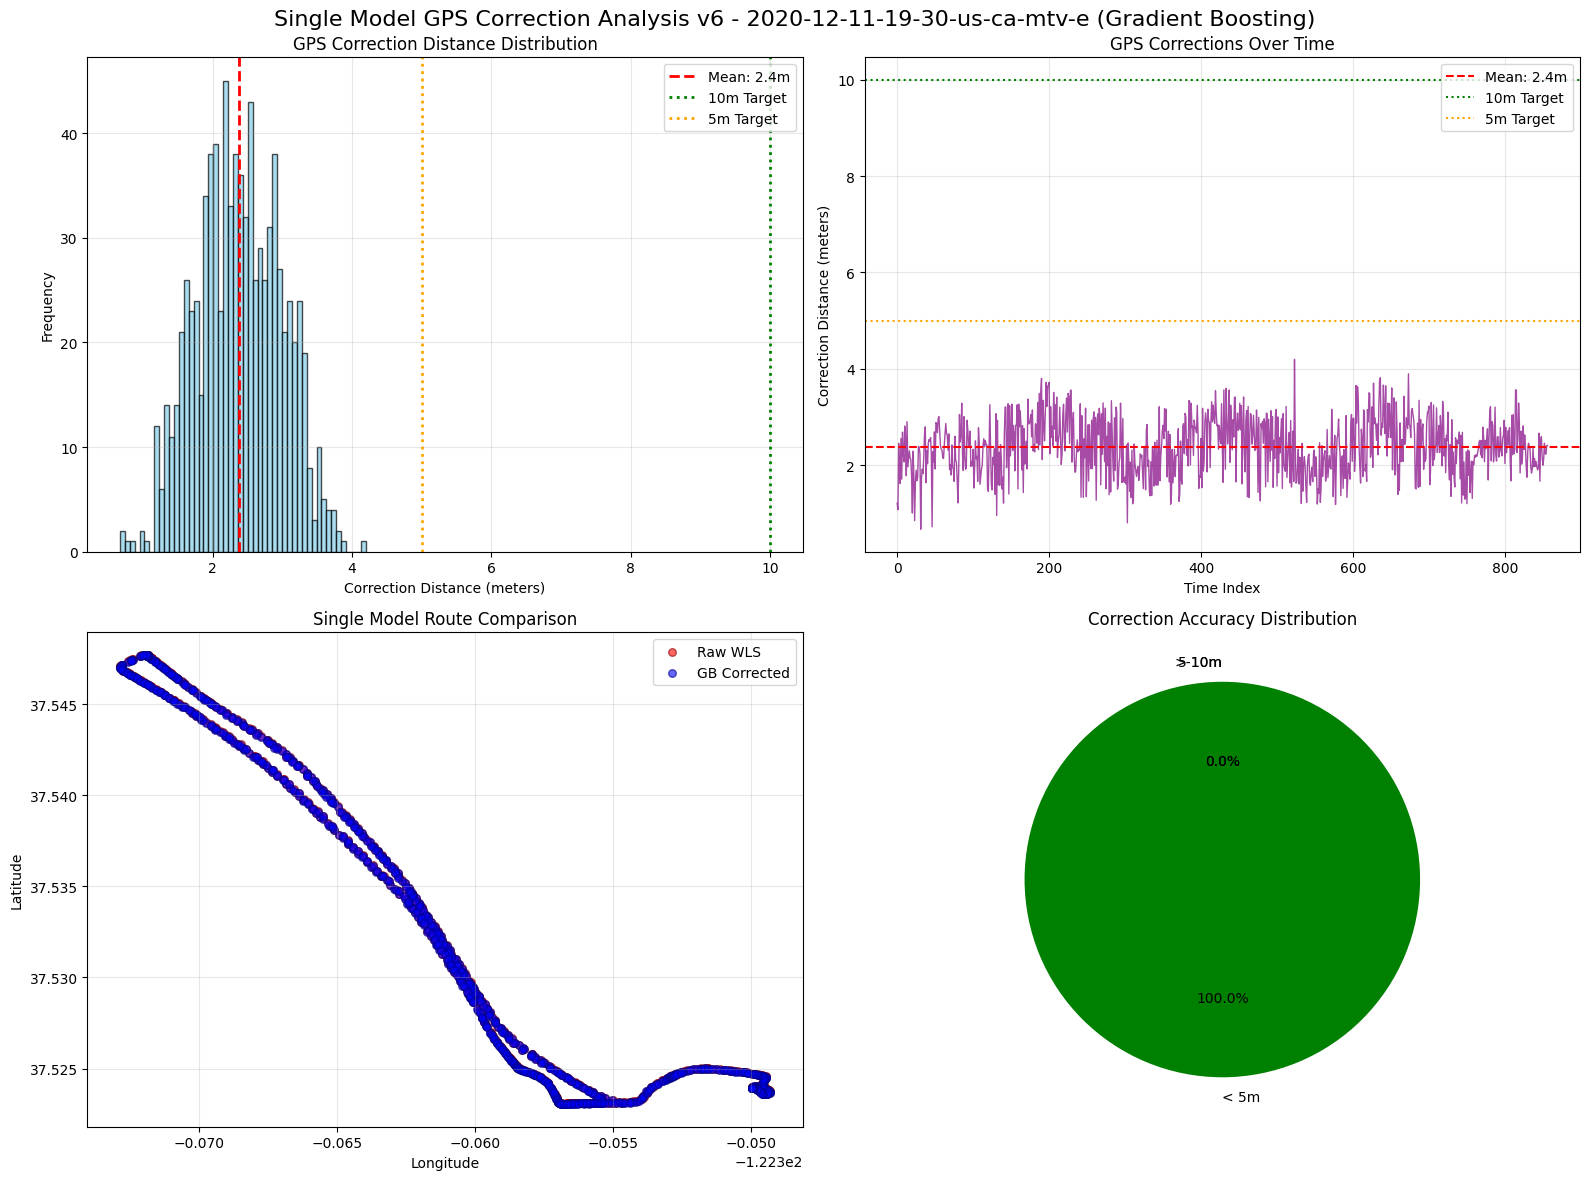


Single model results saved to: single_model_gps_summary_v6_2020-12-11-19-30-us-ca-mtv-e.json


In [13]:
# Cell 11: Single Model Visualization and Analysis
if len(test_sets) > 0 and len(route_data) > 0:
    # Calculate correction distances for single model
    correction_distances = []
    for i in range(len(route_data)):
        correction_distance = geodesic(
            (route_data.iloc[i]['raw_latitude'], route_data.iloc[i]['raw_longitude']),
            (route_data.iloc[i]['corrected_latitude'], route_data.iloc[i]['corrected_longitude'])
        ).meters
        correction_distances.append(correction_distance)

    # Single model statistics
    mean_correction = np.mean(correction_distances)
    median_correction = np.median(correction_distances)
    p95_correction = np.percentile(correction_distances, 95)
    under_10m = (np.array(correction_distances) < 10).mean() * 100
    under_5m = (np.array(correction_distances) < 5).mean() * 100

    print("=== SINGLE MODEL PERFORMANCE (v6) ===")
    print(f"🎯 TARGET: Sub-10m GPS Corrections")
    print(f"Model: Gradient Boosting Only")
    print(f"")
    print(f"📊 Results:")
    print(f"  Mean Correction:     {mean_correction:.2f}m")
    print(f"  Median Correction:   {median_correction:.2f}m")
    print(f"  95th Percentile:     {p95_correction:.2f}m")
    print(f"  % Under 10m:         {under_10m:.1f}%")
    print(f"  % Under 5m:          {under_5m:.1f}%")
    print(f"")

    # Success evaluation
    if mean_correction < 5:
        print("🏆 EXCELLENT: Sub-5m accuracy achieved!")
    elif mean_correction < 10:
        print("✅ SUCCESS: Sub-10m target achieved!")
    elif mean_correction < 15:
        print("🟡 GOOD: Close to 10m target")
    else:
        print("❌ NEEDS IMPROVEMENT: Above 15m")

    # Create single model visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Single Model GPS Correction Analysis v6 - {test_set["date"]} (Gradient Boosting)', fontsize=16)

    # Single model plots
    axes[0, 0].hist(correction_distances, bins=50, alpha=0.7, edgecolor='black', color='skyblue')
    axes[0, 0].axvline(mean_correction, color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {mean_correction:.1f}m')
    axes[0, 0].axvline(10, color='green', linestyle=':', linewidth=2, label='10m Target')
    axes[0, 0].axvline(5, color='orange', linestyle=':', linewidth=2, label='5m Target')
    axes[0, 0].set_xlabel('Correction Distance (meters)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('GPS Correction Distance Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Single model route comparison
    axes[1, 0].scatter(route_data['raw_longitude'], route_data['raw_latitude'], 
                       c='red', alpha=0.6, s=30, label='Raw WLS', edgecolors='darkred')
    axes[1, 0].scatter(route_data['corrected_longitude'], route_data['corrected_latitude'], 
                       c='blue', alpha=0.6, s=30, label='GB Corrected', edgecolors='darkblue')
    axes[1, 0].set_xlabel('Longitude')
    axes[1, 0].set_ylabel('Latitude')
    axes[1, 0].set_title('Single Model Route Comparison')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Correction performance over time
    time_points = range(len(correction_distances))
    axes[0, 1].plot(time_points, correction_distances, alpha=0.7, color='purple', linewidth=1)
    axes[0, 1].axhline(mean_correction, color='red', linestyle='--', label=f'Mean: {mean_correction:.1f}m')
    axes[0, 1].axhline(10, color='green', linestyle=':', label='10m Target')
    axes[0, 1].axhline(5, color='orange', linestyle=':', label='5m Target')
    axes[0, 1].set_xlabel('Time Index')
    axes[0, 1].set_ylabel('Correction Distance (meters)')
    axes[0, 1].set_title('GPS Corrections Over Time')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Performance summary
    performance_data = [under_5m, under_10m-under_5m, 100-under_10m]
    performance_labels = ['< 5m', '5-10m', '> 10m']
    colors = ['green', 'orange', 'red']
    axes[1, 1].pie(performance_data, labels=performance_labels, colors=colors, 
                   autopct='%1.1f%%', startangle=90)
    axes[1, 1].set_title('Correction Accuracy Distribution')

    plt.tight_layout()
    plt.savefig(f'single_model_gps_correction_v6_{test_set["date"]}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Save single model results
    single_model_summary = {
        'model_version': 'v6_single_model',
        'model_type': 'gradient_boosting',
        'test_set': test_set['date'],
        'total_points': int(len(correction_distances)),
        'mean_correction_m': float(mean_correction),
        'median_correction_m': float(median_correction),
        'p95_correction_m': float(p95_correction),
        'percent_under_5m': float(under_5m),
        'percent_under_10m': float(under_10m),
        'target_achieved': bool(mean_correction < 10),
        'excellence_achieved': bool(mean_correction < 5)
    }

    with open(f'single_model_gps_summary_v6_{test_set["date"]}.json', 'w') as f:
        json.dump(single_model_summary, f, indent=2)

    print(f"\nSingle model results saved to: single_model_gps_summary_v6_{test_set['date']}.json")
else:
    print("⚠️  No test data available for visualization")

In [14]:
# Cell 12: Interactive Map Visualization - Single Model (Gradient Boosting)
if len(test_sets) > 0 and len(route_data) > 0:
    print("=== CREATING INTERACTIVE MAP COMPARISON (SINGLE MODEL) ===")
    print("Model: Gradient Boosting Only")
    
    # Calculate center point for map
    center_lat = (route_data['raw_latitude'].mean() + route_data['corrected_latitude'].mean()) / 2
    center_lng = (route_data['raw_longitude'].mean() + route_data['corrected_longitude'].mean()) / 2
    
    # Create the map
    m = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=15,
        tiles='OpenStreetMap'
    )
    
    # Calculate correction distances for map display
    correction_distances_map = []
    for i in range(len(route_data)):
        correction_distance = geodesic(
            (route_data.iloc[i]['raw_latitude'], route_data.iloc[i]['raw_longitude']),
            (route_data.iloc[i]['corrected_latitude'], route_data.iloc[i]['corrected_longitude'])
        ).meters
        correction_distances_map.append(correction_distance)
    
    mean_correction_map = np.mean(correction_distances_map)
    
    # Add raw GPS points (red)
    raw_points = []
    for i, row in route_data.iterrows():
        raw_points.append([row['raw_latitude'], row['raw_longitude']])
        folium.CircleMarker(
            location=[row['raw_latitude'], row['raw_longitude']],
            radius=4,
            popup=f"Raw GPS Point {i+1}<br>Lat: {row['raw_latitude']:.6f}<br>Lng: {row['raw_longitude']:.6f}",
            color='red',
            fillColor='red',
            fillOpacity=0.7,
            weight=2
        ).add_to(m)
    
    # Add corrected GPS points (blue)
    corrected_points = []
    for i, row in route_data.iterrows():
        corrected_points.append([row['corrected_latitude'], row['corrected_longitude']])
        folium.CircleMarker(
            location=[row['corrected_latitude'], row['corrected_longitude']],
            radius=4,
            popup=f"GB Corrected Point {i+1}<br>Lat: {row['corrected_latitude']:.6f}<br>Lng: {row['corrected_longitude']:.6f}<br>Correction: {correction_distances_map[i]:.2f}m",
            color='blue',
            fillColor='blue',
            fillOpacity=0.7,
            weight=2
        ).add_to(m)
    
    # Add polylines to show routes
    folium.PolyLine(
        locations=raw_points,
        color='red',
        weight=3,
        opacity=0.8,
        popup='Raw GPS Route'
    ).add_to(m)
    
    folium.PolyLine(
        locations=corrected_points,
        color='blue',
        weight=3,
        opacity=0.8,
        popup='GB Corrected Route'
    ).add_to(m)
    
    # Add correction lines (connecting raw to corrected points)
    for i, row in route_data.iterrows():
        if correction_distances_map[i] > 1:  # Only show lines for corrections > 1m
            folium.PolyLine(
                locations=[
                    [row['raw_latitude'], row['raw_longitude']],
                    [row['corrected_latitude'], row['corrected_longitude']]
                ],
                color='green',
                weight=1,
                opacity=0.6,
                popup=f'Correction: {correction_distances_map[i]:.2f}m'
            ).add_to(m)
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 220px; height: 140px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <h4>Single Model GPS Correction</h4>
    <p><span style="color:red;">●</span> Raw GPS Points</p>
    <p><span style="color:blue;">●</span> GB Corrected Points</p>
    <p><span style="color:green;">—</span> Correction Vectors</p>
    <p>Model: Gradient Boosting</p>
    <p>Mean Correction: {:.2f}m</p>
    </div>
    '''.format(mean_correction_map)
    
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Add markers for start and end points
    folium.Marker(
        location=[route_data.iloc[0]['corrected_latitude'], route_data.iloc[0]['corrected_longitude']],
        popup='Start Point (GB Corrected)',
        icon=folium.Icon(color='green', icon='play')
    ).add_to(m)
    
    folium.Marker(
        location=[route_data.iloc[-1]['corrected_latitude'], route_data.iloc[-1]['corrected_longitude']],
        popup='End Point (GB Corrected)',
        icon=folium.Icon(color='red', icon='stop')
    ).add_to(m)
    
    # Save the map
    map_filename = f'single_model_gps_map_v6_{test_set["date"]}.html'
    m.save(map_filename)
    
    print(f"✅ Interactive map saved as: {map_filename}")
    print(f"📍 Map shows {len(route_data)} GPS points with single model corrections")
    print(f"🗺️  Red points: Raw GPS positions")
    print(f"🗺️  Blue points: Gradient Boosting corrected positions")
    print(f"🗺️  Green lines: Correction vectors (>1m only)")
    print(f"📊 Mean correction distance: {mean_correction_map:.2f}m")
    
    # Display the map in the notebook
    try:
        display(m)
    except NameError:
        print(f"💡 Open {map_filename} in your browser to view the interactive map")
    
    # Additional statistics for the map
    large_corrections = [d for d in correction_distances_map if d > 10]
    medium_corrections = [d for d in correction_distances_map if 5 <= d <= 10]
    small_corrections = [d for d in correction_distances_map if d < 5]
    
    print(f"\n📈 Correction Distance Analysis:")
    print(f"   Large corrections (>10m): {len(large_corrections)} points")
    print(f"   Medium corrections (5-10m): {len(medium_corrections)} points")
    print(f"   Small corrections (<5m): {len(small_corrections)} points")
    
    if len(large_corrections) > 0:
        print(f"   Largest correction: {max(correction_distances_map):.2f}m")
        max_idx = correction_distances_map.index(max(correction_distances_map))
        print(f"   Location: ({route_data.iloc[max_idx]['raw_latitude']:.6f}, {route_data.iloc[max_idx]['raw_longitude']:.6f})")
    
else:
    print("⚠️  No route data available for map visualization")
    print("   Please run Cells 10-11 first to generate test data")

=== CREATING INTERACTIVE MAP COMPARISON (SINGLE MODEL) ===
Model: Gradient Boosting Only
✅ Interactive map saved as: single_model_gps_map_v6_2020-12-11-19-30-us-ca-mtv-e.html
📍 Map shows 857 GPS points with single model corrections
🗺️  Red points: Raw GPS positions
🗺️  Blue points: Gradient Boosting corrected positions
🗺️  Green lines: Correction vectors (>1m only)
📊 Mean correction distance: 2.38m



📈 Correction Distance Analysis:
   Large corrections (>10m): 0 points
   Medium corrections (5-10m): 0 points
   Small corrections (<5m): 857 points


In [15]:
import os
import pandas as pd
import numpy as np

# List available dates and phones
base_path = 'smartphone-decimeter-2023/sdc2023/train/'
dates = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
if not dates:
    raise FileNotFoundError('No date folders found in train directory.')

# Pick the first available date and phone
for date in dates:
    date_path = os.path.join(base_path, date)
    phones = [p for p in os.listdir(date_path) if os.path.isdir(os.path.join(date_path, p))]
    if phones:
        phone = phones[0]
        print(f"Using date: {date}, phone: {phone}")
        break
else:
    raise FileNotFoundError('No valid phone folders found in any date directory.')

# Build file paths
gnss_path = os.path.join(base_path, date, phone, 'device_gnss.csv')
imu_path = os.path.join(base_path, date, phone, 'device_imu.csv')
gt_path = os.path.join(base_path, date, phone, 'ground_truth.csv')

# Check files exist
for path in [gnss_path, imu_path, gt_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

# Load data
gnss = pd.read_csv(gnss_path)
imu = pd.read_csv(imu_path)
gt = pd.read_csv(gt_path)

# Standardize column names if needed
if 'UnixTimeMillis' in gnss.columns:
    gnss = gnss.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
if 'UnixTimeMillis' in imu.columns:
    imu = imu.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
if 'UnixTimeMillis' in gt.columns:
    gt = gt.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
if 'MessageType' in imu.columns:
    imu = imu.rename(columns={'MessageType': 'IMU_MessageType'})

# Merge GNSS and IMU
gnss_imu = pd.merge_asof(
    gnss.sort_values('utcTimeMillis'),
    imu.sort_values('utcTimeMillis'),
    on='utcTimeMillis',
    direction='nearest',
    tolerance=50
 )

# Merge with ground truth
data = pd.merge_asof(
    gnss_imu.sort_values('utcTimeMillis'),
    gt.sort_values('utcTimeMillis'),
    on='utcTimeMillis',
    direction='nearest',
    tolerance=50
 ).dropna(subset=['LatitudeDegrees', 'LongitudeDegrees'])

# Use the feature set from the notebook
features = [
    'Cn0DbHz', 'Svid', 'SvElevationDegrees', 'SvAzimuthDegrees',
    'IMU_MessageType', 'MeasurementX', 'MeasurementY', 'MeasurementZ',
    'BiasX', 'BiasY', 'BiasZ',
    'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters'
 ]

# Add derived features if present
if 'Cn0DbHz' in data.columns and 'SvElevationDegrees' in data.columns:
    data['SignalQuality'] = data['Cn0DbHz'] * np.sin(np.radians(data['SvElevationDegrees']))
if 'WlsPositionXEcefMeters' in data.columns:
    data['WLS_Distance'] = np.sqrt(
        data['WlsPositionXEcefMeters']**2 +
        data['WlsPositionYEcefMeters']**2 +
        data['WlsPositionZEcefMeters']**2
    )

# Add ground truth columns for comparison
data['LatitudeDegrees_gt'] = data['LatitudeDegrees']
data['LongitudeDegrees_gt'] = data['LongitudeDegrees']

# Select columns for output (features + derived + ground truth)
output_cols = features + ['SignalQuality', 'WLS_Distance', 'LatitudeDegrees_gt', 'LongitudeDegrees_gt']
output_cols = [col for col in output_cols if col in data.columns]
test_sample = data[output_cols].head(20)

test_sample.to_csv('test_features_with_ground_truth.csv', index=False)
print('Test CSV file created: test_features_with_ground_truth.csv')

Using date: 2020-06-25-00-34-us-ca-mtv-sb-101, phone: pixel4
Test CSV file created: test_features_with_ground_truth.csv
